# Question: Let S be diagonal, $S = diag(\lambda)$, with all $\lambda_i \ge 0$ (important)
# how does $PP(S)$ compare to $\nu(\lambda)$ ?
# i.e. what is the effect of the row-demeaning?
# Try this for $\lambda$ drawn from (i) uniform, (ii) Pareto, (iii) Cauchy
# Answer: for all three, $PP(S) \approx \nu(\lambda)$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

In [31]:
d = 200
alpha = 1.0

lambda_S = pp.generate_pareto_draws(d,alpha)
S = np.diag(lambda_S)

pp_dim_S = pp.calculate_PatnaikPearson_dim(S)
#print("PP(S) = ", pp_dim_S)
nu_lambda = pp.calculate_nu(lambda_S)
print("PP(S) = ", pp_dim_S, ", nu(lambda) = ", nu_lambda)
#nu_lambda = pp.

** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
PP(S) =  20.455051952524062 , nu(lambda) =  20.48859527974314


# (i) Uniform

In [32]:
d = 100
num_iterations = 100
#alpha_max = 10.0
#alpha_min = 0.01
#k = math.log(alpha_max / alpha_min)

#alpha_vals = np.zeros(num_iterations)
pp_dim_vals = np.zeros(num_iterations)
nu_lambda_vals = np.zeros(num_iterations)
ratio_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    t = np.random.uniform(0,1)
    #alpha = alpha_min * math.exp(k * t)
    #alpha_vals[i] = alpha
    lambda_S = np.random.uniform(0,1,d) 
    S = np.diag(lambda_S)
    pp_dim_S = pp.calculate_PatnaikPearson_dim(S)
    nu_lambda = pp.calculate_nu(lambda_S)
    print(i, ", PP(S) = ", pp_dim_S, ", nu(lambda) = ", nu_lambda)
    pp_dim_vals[i] = pp_dim_S
    nu_lambda_vals[i] = nu_lambda
    ratio_vals[i] = nu_lambda / pp_dim_S

** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
0 , PP(S) =  74.8590606314237 , nu(lambda) =  75.22715390021921
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
1 , PP(S) =  77.31247780627652 , nu(lambda) =  77.7490781999858
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
2 , PP(S) =  78.26601432890368 , nu(lambda) =  78.70704219827097
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
3 , PP(S) =  75.65879431856963 , nu(lambda) =  76.1172066900933
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
4 , PP(S) =  71.08911302201366 , nu(lambda) =  71.44917492866756
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
5 , PP(S) =  73.74688741509554 , nu(lambda) =  74.13083993251057
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
6 , PP(S) =  73.86863262165784 , nu(lambda) =  74.23248530054771
** calculate_nu_

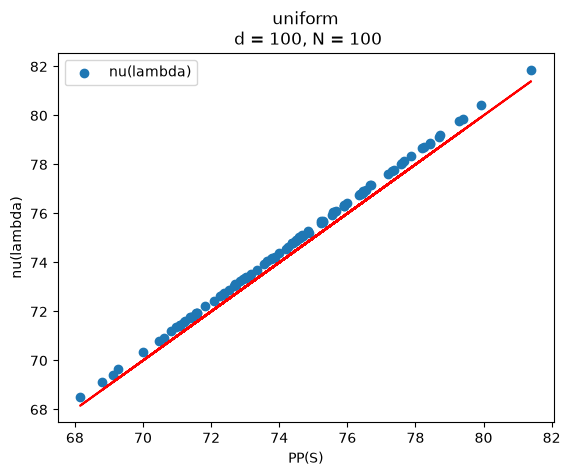

In [33]:
this_title = "uniform"
this_title += "\n d = " + str(d) + ", N = " + str(num_iterations)

plt.scatter(pp_dim_vals, nu_lambda_vals, label = "nu(lambda)")
plt.plot(pp_dim_vals, pp_dim_vals, color = "red")
plt.xlabel("PP(S)")
plt.ylabel("nu(lambda)")
plt.title(this_title)
plt.legend()
plt.show()

# (ii) Pareto

In [3]:
d = 100
num_iterations = 500
alpha_max = 10.0
alpha_min = 0.01
k = math.log(alpha_max / alpha_min)

alpha_vals = np.zeros(num_iterations)
pp_dim_vals = np.zeros(num_iterations)
nu_lambda_vals = np.zeros(num_iterations)
ratio_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    t = np.random.uniform(0,1)
    alpha = alpha_min * math.exp(k * t)
    alpha_vals[i] = alpha
    lambda_S = pp.generate_pareto_draws(d,alpha)
    S = np.diag(lambda_S)
    pp_dim_S = pp.calculate_PatnaikPearson_dim(S)
    nu_lambda = pp.calculate_nu(lambda_S)
    print(i, alpha, ", PP(S) = ", pp_dim_S, ", nu(lambda) = ", nu_lambda)
    pp_dim_vals[i] = pp_dim_S
    nu_lambda_vals[i] = nu_lambda
    ratio_vals[i] = nu_lambda / pp_dim_S
    

** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
0 0.13292918943162163 , PP(S) =  1.0090600987710139 , nu(lambda) =  1.0090608018911829
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
1 0.8113929572637837 , PP(S) =  13.234871245099566 , nu(lambda) =  13.274637261348389
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
2 0.03054120318443386 , PP(S) =  1.0000000000000382 , nu(lambda) =  1.0000000000000129
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
3 0.8171272700715589 , PP(S) =  8.3493686940344 , nu(lambda) =  8.370660668789718
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
4 0.0912323376793708 , PP(S) =  1.004086672445438 , nu(lambda) =  1.0040869847537564
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
5 0.030750403441204676 , PP(S) =  1.000000000000033 , nu(lambda) =  1.0
** calculate_nu_cpu ** running on CPU
** calc

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260618\PatnaikPearson\PatnaikPearson\helper.py:1385: RuntimeWarning: overflow encountered in square
  sum_lambda_i_squared = sum(these_lambdas**2)
C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260618\PatnaikPearson\PatnaikPearson\helper.py:1386: RuntimeWarning: overflow encountered in scalar power
  nu = (sum_lambda_i ** 2) / sum_lambda_i_squared
C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260618\PatnaikPearson\PatnaikPearson\helper.py:1386: RuntimeWarning: invalid value encountered in scalar divide
  nu = (sum_lambda_i ** 2) / sum_lambda_i_squared


** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
17 1.216481998362176 , PP(S) =  11.421750915818423 , nu(lambda) =  11.471665763601349
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
18 0.7481534906556973 , PP(S) =  3.408231933446071 , nu(lambda) =  3.41122451672855
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
19 0.1729280811796462 , PP(S) =  1.00000001591944 , nu(lambda) =  1.000000015920527
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
20 7.765748163444495 , PP(S) =  97.23919419831198 , nu(lambda) =  98.20642263283561
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
21 0.3278085831737686 , PP(S) =  3.0275076754846117 , nu(lambda) =  3.027810230228124
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
22 0.019480648517058427 , PP(S) =  1.0000000001522837 , nu(lambda) =  1.0000000001522529
** calculate_nu_cpu ** running 

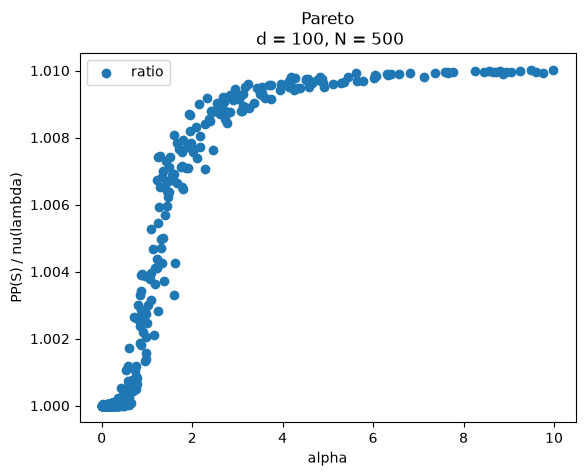

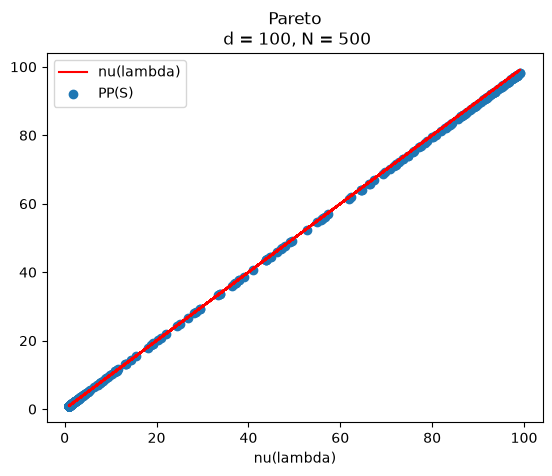

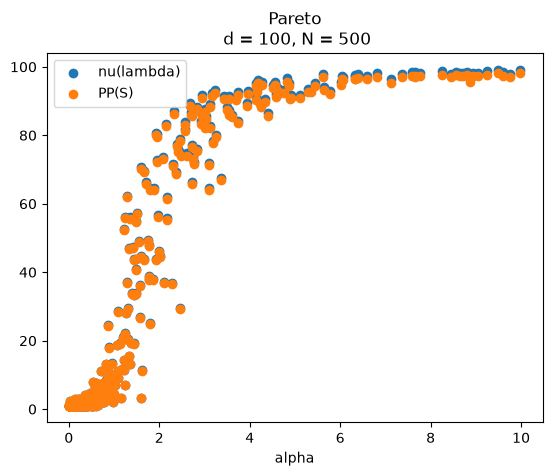

In [4]:
this_title = "Pareto"
this_title += "\n d = " + str(d) + ", N = " + str(num_iterations)

plt.scatter(alpha_vals, ratio_vals, label = "ratio")
plt.xlabel("alpha")
plt.ylabel("PP(S) / nu(lambda)")
plt.title(this_title)
plt.legend()
plt.show()

plt.plot(nu_lambda_vals,nu_lambda_vals, color="red", label = "nu(lambda)")
plt.scatter(nu_lambda_vals, pp_dim_vals, label = "PP(S)")
plt.xlabel("nu(lambda)")
plt.title(this_title)
plt.legend()
plt.show()

plt.scatter(alpha_vals, nu_lambda_vals, label = "nu(lambda)")
plt.scatter(alpha_vals, pp_dim_vals, label = "PP(S)")
plt.xlabel("alpha")
plt.title(this_title)
plt.legend()
plt.show()

# (iii) Cauchy

In [5]:
d = 100
num_iterations = 200

alpha_vals = np.zeros(num_iterations)
pp_dim_vals = np.zeros(num_iterations)
nu_lambda_vals = np.zeros(num_iterations)
ratio_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    lambda_S = np.abs(np.random.standard_cauchy(d))
    print("min(lambda_S) = ", np.min(lambda_S), ", max(lambda_S) = ", np.max(lambda_S))
    S = np.diag(lambda_S)
    pp_dim_S = pp.calculate_PatnaikPearson_dim(S)
    nu_lambda = pp.calculate_nu(lambda_S)
    print(i, alpha, ", PP(S) = ", pp_dim_S, ", nu(lambda) = ", nu_lambda)
    pp_dim_vals[i] = pp_dim_S
    nu_lambda_vals[i] = nu_lambda
    ratio_vals[i] = nu_lambda / pp_dim_S

min(lambda_S) =  0.02297139325742285 , max(lambda_S) =  45.02761555645895
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
0 0.05174025184734099 , PP(S) =  16.158866158030072 , nu(lambda) =  16.189761909921344
min(lambda_S) =  0.004270942813013816 , max(lambda_S) =  206.50353258767657
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
1 0.05174025184734099 , PP(S) =  7.0060794720014545 , nu(lambda) =  7.01527766707218
min(lambda_S) =  0.00623931210545014 , max(lambda_S) =  130.4753667453155
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
2 0.05174025184734099 , PP(S) =  8.775509015914372 , nu(lambda) =  8.786132655736862
min(lambda_S) =  0.012488155627947651 , max(lambda_S) =  14.363354285694866
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
3 0.05174025184734099 , PP(S) =  30.931421014600435 , nu(lambda) =  31.034827705645004
min(lambda_S) =  0.02578788753567872 , max(lambda_S)

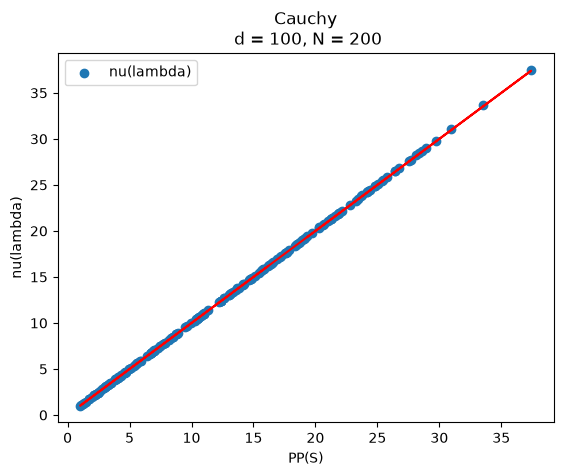

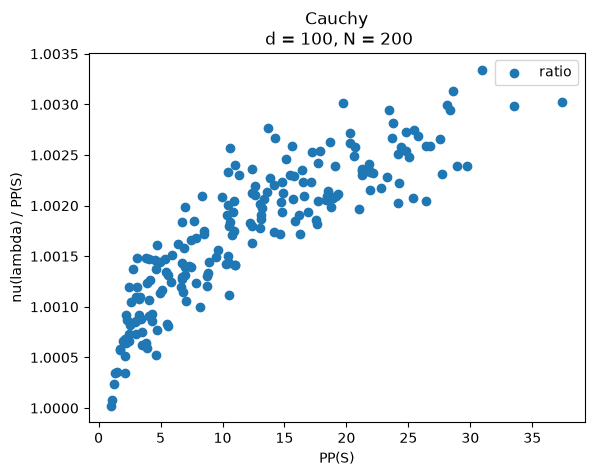

In [8]:
this_title = "Cauchy"
this_title += "\n d = " + str(d) + ", N = " + str(num_iterations)

plt.scatter(pp_dim_vals, nu_lambda_vals, label = "nu(lambda)")
plt.plot(pp_dim_vals, pp_dim_vals, color = "red")
plt.xlabel("PP(S)")
plt.ylabel("nu(lambda)")
plt.title(this_title)
plt.legend()
plt.show()

plt.scatter(pp_dim_vals, ratio_vals, label = "ratio")
plt.xlabel("PP(S)")
plt.ylabel("nu(lambda) / PP(S)")
plt.title(this_title)
plt.legend()
plt.show()